In [17]:
import sys, os
import json, pickle
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import pandas as pd
import time as pytime
import statsmodels.tsa.stattools as tsa
import ruptures as rpt
sys.path.append('../..')
import InsanallyLabEphysTools as ilep
from scipy.stats import gaussian_kde, sem, ttest_ind, ttest_rel, norm, mannwhitneyu, linregress, wilcoxon
from tqdm import tqdm
from types import SimpleNamespace
from sklearn import linear_model
from sklearn.model_selection import KFold
import seaborn as sns
import traceback
from itertools import product
import pingouin as pg

plt.rcParams['legend.fontsize'] = 'small'
plt.rcParams['axes.labelsize'] = 'medium'
plt.rcParams['axes.formatter.limits'] = [-2,3]
plt.rcParams['axes.formatter.use_mathtext'] = True
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['figure.dpi'] = '150'

#Set global font parameters
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = 'Arial'
#Set font type to TrueType for compatibility
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
stdfont = 14
stdyfrac = 0.06
post_SS_opto_thresh = 3.0862320795028393
post_SS_control_thresh = 4.540619954274395
pre_SS_opto_thresh = 4.217619129145052
pre_SS_control_thresh = 3.126442132575556

TARGET_COLOR = '#ff3654'
NONTARGET_COLOR = '#5776ff'
CR_COLOR = '#808080'
NCR_COLOR = '#FF767C'
CNO_COLOR = '#00BFFF'
SWITCH_COLOR = '#B07A3B'
LIGHT_LASER = '#5E92EE'
LASER_COLOR = '#3375E9'
GOOD_GREY = '#969696'
GOOD_GREEN = '#32A852'
NCR_CR_cmap = mpl.colors.LinearSegmentedColormap.from_list('NCR-CR color map', [NCR_COLOR, CR_COLOR], N=1000)
PHASE_COLORS = ['#E2CAE3','#C27AC5','#764979','#B9D3F7','#5181C2','#3C557A']

In [18]:
pre_SS_opto = ['AE_368','AE_369','AE_449']
pre_SS_control = ['AE_363','AE_435','AE_389']
post_SS_opto = ['AE_376','AE_415','AE_469']
post_SS_control = ['AE_391','AE_447','AE_488']

all_animals = np.concatenate([pre_SS_opto, pre_SS_control,post_SS_opto, post_SS_control])

In [19]:
df = pd.read_csv(os.path.join('..','..','Source Data Files','Figure 3s.csv'))

In [20]:
df

,Unnamed: 0,animal,session,cluster ID,condition,FR modulation
0,0,AE_363,AE_363_1_opto_control_AC.pickle,77,pre expert control,5.108225
1,1,AE_363,AE_363_1_opto_control_AC.pickle,78,pre expert control,6.103896
2,2,AE_363,AE_363_1_opto_control_AC.pickle,100,pre expert control,1.774892
3,3,AE_363,AE_363_1_opto_control_AC.pickle,114,pre expert control,1.255411
4,4,AE_363,AE_363_1_opto_control_AC.pickle,119,pre expert control,1.082251
...,...,...,...,...,...,...
529,529,AE_488,AE_488_3_opto_control_AC.pickle,380,post expert control,4.353741
530,530,AE_488,AE_488_3_opto_control_AC.pickle,381,post expert control,6.802721
531,531,AE_488,AE_488_3_opto_control_AC.pickle,383,post expert control,1.292517
532,532,AE_488,AE_488_3_opto_control_AC.pickle,387,post expert control,0.646259


In [21]:
control_post_FRmods = []
opto_post_FRmods = []
control_pre_FRmods = []
opto_pre_FRmods = []


for row in df.iloc():

    if row['animal'] in post_SS_control:
        control_post_FRmods.append(row['FR modulation'])
    if row['animal'] in post_SS_opto:
        opto_post_FRmods.append(row['FR modulation'])
    if row['animal'] in pre_SS_control:
        control_pre_FRmods.append(row['FR modulation'])
    if row['animal'] in pre_SS_opto:
        opto_pre_FRmods.append(row['FR modulation'])


control_post_FRmods = np.array(ilep.rmnan(control_post_FRmods))
opto_post_FRmods = np.array(ilep.rmnan(opto_post_FRmods))
control_pre_FRmods = np.array(ilep.rmnan(control_pre_FRmods))
opto_pre_FRmods = np.array(ilep.rmnan(opto_pre_FRmods))

In [22]:
mean_pc_NCR_control_post = []
sem_pc_NCR_control_post = []
for FRmods in [[control_post_FRmods]]:
    Mw,SEMw = ilep.bootstrap_Mw_SEMw(FRmods,n_frac=1,CR_NCR_thresh=post_SS_control_thresh)
    mean_pc_NCR_control_post.append(Mw)
    sem_pc_NCR_control_post.append(SEMw)

mean_pc_NCR_post = []
sem_pc_NCR_post = []
for FRmods in [[opto_post_FRmods]]:
    Mw,SEMw = ilep.bootstrap_Mw_SEMw(FRmods,n_frac=1,CR_NCR_thresh=post_SS_opto_thresh)
    mean_pc_NCR_post.append(Mw)
    sem_pc_NCR_post.append(SEMw)

mean_pc_NCR_control_pre = []
sem_pc_NCR_control_pre = []
for FRmods in [[control_pre_FRmods]]:
    # print(len(FRmods))
    Mw,SEMw = ilep.bootstrap_Mw_SEMw(FRmods,n_frac=1,CR_NCR_thresh=pre_SS_control_thresh)
    mean_pc_NCR_control_pre.append(Mw)
    sem_pc_NCR_control_pre.append(SEMw)

mean_pc_NCR_pre = []
sem_pc_NCR_pre = []
for FRmods in [[opto_pre_FRmods]]:
    Mw,SEMw = ilep.bootstrap_Mw_SEMw(FRmods,n_frac=1,CR_NCR_thresh=pre_SS_opto_thresh)
    mean_pc_NCR_pre.append(Mw)
    sem_pc_NCR_pre.append(SEMw)

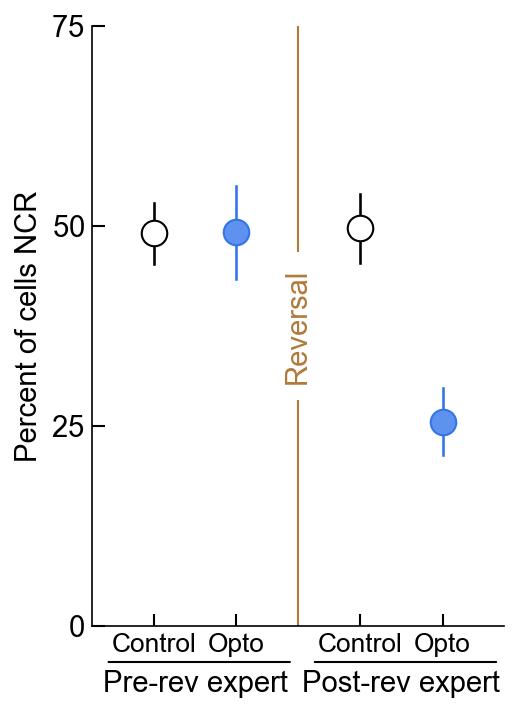

In [23]:
def add_axis_size(fig, ax_w, ax_h, left, bottom):
    fig_w, fig_h = fig.get_size_inches()
    ax = fig.add_axes([left/fig_w, bottom/fig_h, ax_w/fig_w, ax_h/fig_h])
    return ax

def make_axis_size(ax_w, ax_h, left=.3, bottom=.3, right=0, top=0):
    fig_w = (ax_w + left + right) * 1.05
    fig_h = (ax_h + bottom + top) * 1.05
    fig = plt.figure(figsize=(fig_w, fig_h))
    ax = add_axis_size(fig, ax_w, ax_h, left, bottom)
    return fig, ax

def statsbar(ax,barheight,xpoints,stemheights,text=None,lw=1):
    ymax = ax.get_ylim()[1]
    ymin = ax.get_ylim()[0]
    yrange = ymax-ymin
    ydist = 0.025*yrange
    
    ax.plot([xpoints[0]]*2,[stemheights[0]+ydist,barheight],lw=lw,color='k')
    ax.plot([xpoints[1]]*2,[stemheights[1]+ydist,barheight],lw=lw,color='k')
    ax.plot(xpoints,[barheight]*2,lw=lw,color='k')
    
    if not text is None:
        ax.text(np.mean(xpoints),barheight + ydist,text,horizontalalignment='center',verticalalignment='center')

fig,ax = make_axis_size(2.75, 4, left=.3, bottom=.3, right=0, top=0)
switch_offset = 0#0.1

################################################################################################################

data = [mean_pc_NCR_control_pre,mean_pc_NCR_pre, mean_pc_NCR_control_post,mean_pc_NCR_post]
sems = [sem_pc_NCR_control_pre,sem_pc_NCR_pre, sem_pc_NCR_control_post,sem_pc_NCR_post]

wid = 0
p = 1
offset=0.333
sz = 150

width = 0.3
switch_offset = 0.25

for idx,(column,polarity) in enumerate(zip(data,[-1,-1,1,1])):
    Y = column
    if idx % 2 ==0:
        ax.scatter(idx+polarity*switch_offset,Y,fc='white',ec='k',s=sz,marker='o',zorder=10)
        ax.plot([idx+polarity*switch_offset,idx+polarity*switch_offset],[column[0]-sems[idx], column[0]+sems[idx]],color='k',lw=1.25,zorder=9)
    else:
        ax.scatter(idx+polarity*switch_offset,Y,fc=LIGHT_LASER,ec=LASER_COLOR,s=sz,marker='o',zorder=10)
        ax.plot([idx+polarity*switch_offset,idx+polarity*switch_offset],[column[0]-sems[idx], column[0]+sems[idx]],color=LASER_COLOR,lw=1.25,zorder=9)

################################################################################################################

ylab = ax.set_ylabel('Percent of cells NCR')
ax.set_ylim([0,75])
ax.set_yticks([0,25,50,75])
              
ax.set_xlim([-0.75-switch_offset,3+switch_offset])
ax.set_xticks([0-offset,0+offset])

ax.set_xlim([-0.75-switch_offset,3.75+switch_offset])
ax.set_xticks([0-switch_offset,1-switch_offset,2+switch_offset,3+switch_offset])
ax.set_xticklabels(['Control','Opto','Control','Opto'])

xtick_pos_pre = np.mean(ax.get_xticks()[:2])
xtick_pos_post = np.mean(ax.get_xticks()[2:4])
Yval = ilep.getPrePostLabelYval(ax.get_ylim(),Yfrac=-2*stdyfrac)
t1 = ax.text(xtick_pos_pre, Yval, 'Pre-rev expert', ha='center', va='bottom', fontsize=stdfont,color='k')
t2 = ax.text(xtick_pos_post, Yval, 'Post-rev expert', ha='center', va='bottom',  fontsize=stdfont,color='k')
ax.annotate('', xy=(0.03, -stdyfrac), xycoords='axes fraction', xytext=(0.49, -stdyfrac),arrowprops=dict(arrowstyle='-', color='black'))
ax.annotate('', xy=(0.53, -stdyfrac), xycoords='axes fraction', xytext=(0.99, -stdyfrac),arrowprops=dict(arrowstyle='-', color='black'))
Y = np.mean(ax.get_ylim())
X = np.mean(ax.get_xlim())
t = ax.text(X,Y,'Reversal',rotation=90,fontsize=stdfont,color=SWITCH_COLOR,horizontalalignment='center',verticalalignment='center')
ax.plot([X]*2,[ax.get_ylim()[0],Y-np.ptp(ax.get_ylim())*0.125],lw=1,color=SWITCH_COLOR)
ax.plot([X]*2,[ax.get_ylim()[1],Y+np.ptp(ax.get_ylim())*0.125],lw=1,color=SWITCH_COLOR)

ax.tick_params(direction='in', length=6, width=1)

for item in ([ax.title, ax.xaxis.label, ax.yaxis.label,t1,t2] +
    ax.get_xticklabels() + ax.get_yticklabels()):
    item.set_fontsize(stdfont)
for item in ax.get_xticklabels():
    item.set_fontsize(stdfont*0.9)
    pass

artists = [ylab,t1,t2]

# fig.savefig(os.path.join('..','..','Figures','Figure 3s.pdf'),transparent=False,facecolor="white",dpi=400, bbox_extra_artists=(artists), bbox_inches='tight')

In [24]:
pval = ilep.bootstrap_pc_NCR_test([control_pre_FRmods],[opto_pre_FRmods],B=25000,CR_NCR_thresh=[pre_SS_control_thresh,pre_SS_opto_thresh])
print('Pre expert Opto vs control')
print(f'p = {pval}\n')

pval = ilep.bootstrap_pc_NCR_test([control_post_FRmods],[opto_post_FRmods],B=25000,CR_NCR_thresh=[post_SS_control_thresh,post_SS_opto_thresh])
print('Post expert Opto vs control')
print(f'p = {pval}')

Pre expert Opto vs control
p = 0.9532

Post expert Opto vs control
p = 8.000000000008001e-05
